# Clustering strategy — step by step

How we go from raw prices to a **family-based mean-reversion** strategy, with the code and a
chart behind every number. Run top to bottom.

**Score journey:** raw reversion **85** → market-neutral **91** → **family / clustering 134** (Sharpe 2.16).

In [1]:
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from scipy.spatial.distance import squareform
import research as R

# clean, colourblind-safe styling, recessive grid
CAT = ['#0072B2', '#E69F00', '#009E73', '#D55E00', '#CC79A7', '#56B4E9']  # 6 distinct hues
BUY, SELL = '#0072B2', '#D55E00'                                          # long / short pair
plt.rcParams.update({
    'figure.figsize': (9, 4.5), 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.25, 'grid.linewidth': 0.6,
    'axes.titlesize': 12, 'axes.titleweight': 'bold', 'font.size': 10,
})

prices = R.loadPrices()                                   # shape (assets, days)
tickers = pd.read_csv('prices.txt', sep=r'\s+').columns.to_numpy()
nInst, nDays = prices.shape
print(f'{nInst} assets, {nDays} days')
print('first few tickers:', list(tickers[:8]))

51 assets, 500 days
first few tickers: ['ALGO', 'AENO', 'LSST', 'SRNA', 'ELLT', 'AMRP', 'OTCS', 'HETT']


## 1. The data

51 price series, 500 days. Six of them below, each indexed to 100 on day 0 so we can compare shapes.

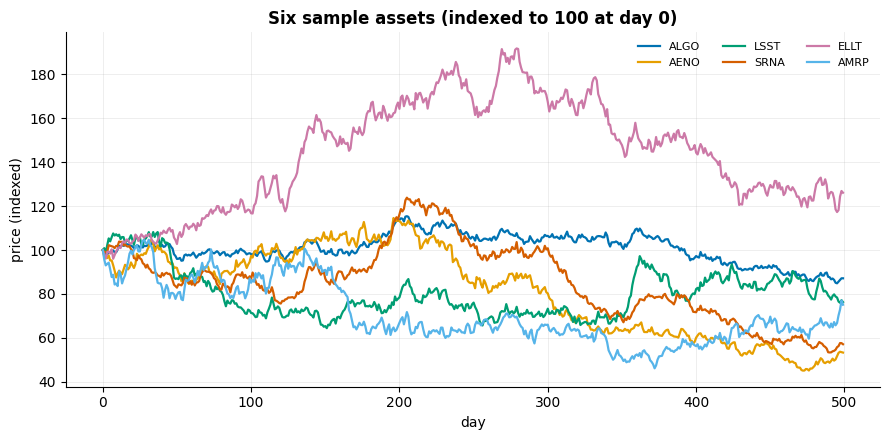

In [2]:
fig, ax = plt.subplots()
for i in range(6):
    ax.plot(prices[i] / prices[i, 0] * 100, color=CAT[i], lw=1.6, label=tickers[i])
ax.set_title('Six sample assets (indexed to 100 at day 0)')
ax.set_xlabel('day'); ax.set_ylabel('price (indexed)')
ax.legend(ncol=3, frameon=False, fontsize=8)
plt.tight_layout(); plt.show()

## 2. Which assets move together?

We work with **daily moves** (log returns), not raw prices. Over the last 120 days we measure how
correlated every pair of assets is. **Red = move together, blue = move oppositely, white = unrelated.**

correlation matrix shape: (51, 51)
average off-diagonal correlation: +0.197


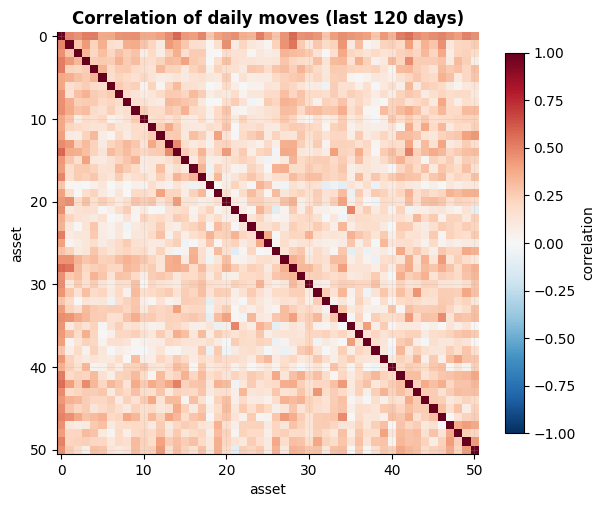

In [3]:
CW = 120
logRet = np.diff(np.log(prices), axis=1)          # daily moves, shape (assets, days-1)
corr = np.corrcoef(logRet[:, -CW:])
print('correlation matrix shape:', corr.shape)
print(f'average off-diagonal correlation: {corr[np.triu_indices(nInst, 1)].mean():+.3f}')

fig, ax = plt.subplots(figsize=(6.2, 5.4))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_title(f'Correlation of daily moves (last {CW} days)')
ax.set_xlabel('asset'); ax.set_ylabel('asset')
fig.colorbar(im, ax=ax, shrink=0.8, label='correlation')
plt.tight_layout(); plt.show()

## 3. Grouping into families

Turn correlation into a **distance** (`distance = 1 - correlation`), let hierarchical clustering build
a tree, then cut it into 6 families. The dendrogram shows how assets merge; colours mark the families.

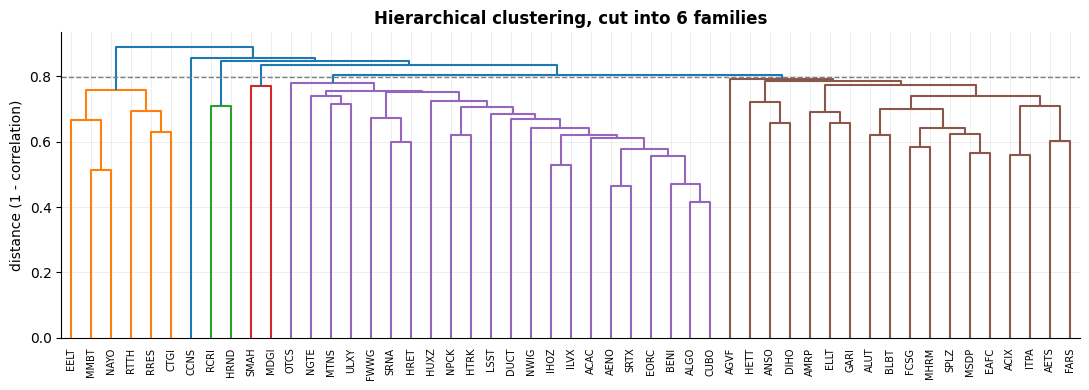

In [4]:
dist = np.clip(1 - corr, 0, None); np.fill_diagonal(dist, 0); dist = (dist + dist.T) / 2
Z = linkage(squareform(dist, checks=False), method='average')

K = 6
cut = 0.5 * (Z[-K, 2] + Z[-(K-1), 2])             # threshold that yields exactly K groups
fig, ax = plt.subplots(figsize=(11, 4))
dendrogram(Z, labels=tickers, color_threshold=cut, leaf_font_size=7, ax=ax)
ax.axhline(cut, color='0.5', ls='--', lw=1)
ax.set_title(f'Hierarchical clustering, cut into {K} families')
ax.set_ylabel('distance (1 - correlation)')
plt.tight_layout(); plt.show()

Family 1 ( 6): RTTH, MMBT, RRES, CTGI, NAYO, EELT
Family 2 ( 2): RCRI, HRND
Family 3 ( 2): SMAH, MDGI
Family 4 (22): ALGO, AENO, LSST, SRNA, OTCS, HUXZ, DUCT, NPCK, EORC, CUBO, HRET, NWIG, ACAC, SRTX, MTNS, IHOZ, FWWG, ULXY, BENI, HTRK, NGTE, ILVX
Family 5 (18): ELLT, AMRP, HETT, MSDP, ANSO, DIHO, SPLZ, AGVF, ALUT, GARI, ACIX, AETS, BLBT, ITPA, FCSG, FARS, MHRM, EAFC
Family 6 ( 1): CCNS


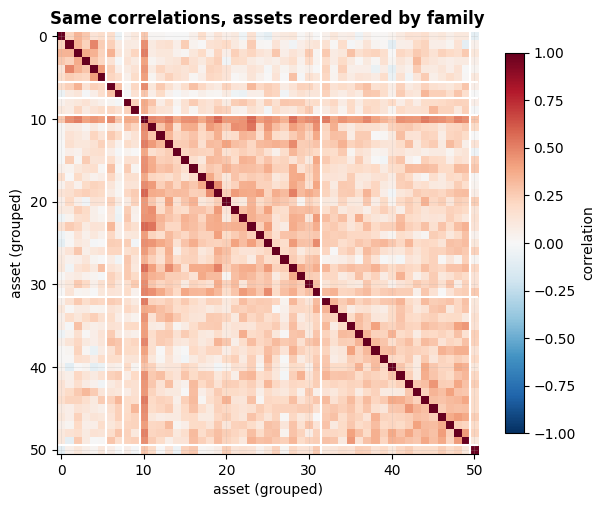

In [5]:
labels = fcluster(Z, t=K, criterion='maxclust')
for c in range(1, K + 1):
    members = tickers[labels == c]
    print(f'Family {c} ({len(members):2d}): {", ".join(members)}')

# reorder assets by family -> red blocks should appear on the diagonal (proof families are real)
order = np.argsort(labels, kind='stable')
fig, ax = plt.subplots(figsize=(6.2, 5.4))
im = ax.imshow(corr[np.ix_(order, order)], cmap='RdBu_r', vmin=-1, vmax=1)
for b in np.cumsum(np.bincount(labels)[1:])[:-1]:
    ax.axhline(b - 0.5, color='white', lw=1.5); ax.axvline(b - 0.5, color='white', lw=1.5)
ax.set_title('Same correlations, assets reordered by family')
ax.set_xlabel('asset (grouped)'); ax.set_ylabel('asset (grouped)')
fig.colorbar(im, ax=ax, shrink=0.8, label='correlation')
plt.tight_layout(); plt.show()

## 4. The signal: how far each asset pulled from its family

Inside each family we strip out the shared family move and keep the **leftover** (each asset's own
wandering) over the last 60 days. Ran far ahead of the family → **short** it; lagged behind → **buy** it.

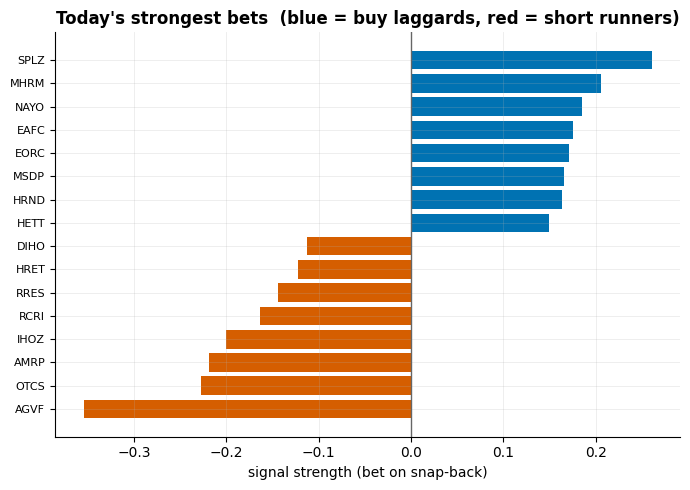

In [6]:
W = 60
recentW = logRet[:, -W:]
pull = np.zeros(nInst)
for c in np.unique(labels):
    idx = np.where(labels == c)[0]
    if len(idx) < 2: continue
    fam = recentW[idx].mean(0); fc = fam - fam.mean(); den = fc @ fc
    if den <= 0: continue
    mc = recentW[idx] - recentW[idx].mean(1, keepdims=True)
    pull[idx] = (recentW[idx] - np.outer((mc @ fc) / den, fam)).sum(1)

sig = -(pull - pull.mean())                       # +ve = buy, -ve = short
o = np.argsort(sig); picks = np.concatenate([o[:8], o[-8:]]); vals = sig[picks]
fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(range(len(picks)), vals, color=[SELL if v < 0 else BUY for v in vals])
ax.set_yticks(range(len(picks))); ax.set_yticklabels(tickers[picks], fontsize=8)
ax.axvline(0, color='0.4', lw=1)
ax.set_title("Today's strongest bets  (blue = buy laggards, red = short runners)")
ax.set_xlabel('signal strength (bet on snap-back)')
plt.tight_layout(); plt.show()

## 5. Does it make money?

We plug the strategy into the same scoring code the official grader uses (`research.backtest`
reproduces `eval.py` exactly). Below is the equity curve — cumulative profit over the 250 scored days.

Score 133.7 | Sharpe 2.16 | mean daily PnL $162 | avg daily $ traded 99,984


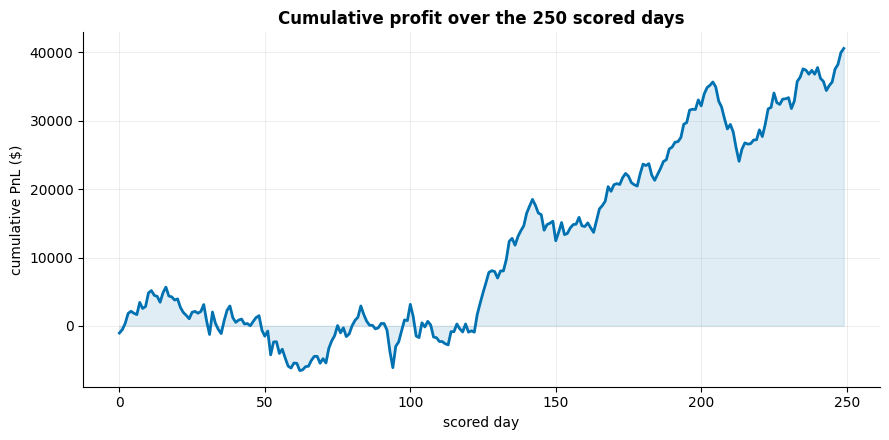

In [7]:
CLUSTER_WINDOW, N_CLUSTERS, REVERT_WINDOW, VOL_WINDOW, GROSS = 120, 6, 60, 20, 1_000_000

def family_labels(lr):
    C = np.nan_to_num(np.corrcoef(lr), nan=0.0)
    D = np.clip(1 - C, 0, None); np.fill_diagonal(D, 0); D = (D + D.T) / 2
    return fcluster(linkage(squareform(D, checks=False), method='average'),
                    t=N_CLUSTERS, criterion='maxclust')

def getMyPosition(prcSoFar):
    nI, nt = prcSoFar.shape
    if nt < CLUSTER_WINDOW + 2: return np.zeros(nI)
    px = prcSoFar[:, -1]; dr = np.diff(np.log(prcSoFar), axis=1)
    lab = family_labels(dr[:, -CLUSTER_WINDOW:]); rc = dr[:, -REVERT_WINDOW:]; pull = np.zeros(nI)
    for c in np.unique(lab):
        idx = np.where(lab == c)[0]
        if len(idx) < 2: continue
        fam = rc[idx].mean(0); fc = fam - fam.mean(); den = fc @ fc
        if den <= 0: continue
        mc = rc[idx] - rc[idx].mean(1, keepdims=True)
        pull[idx] = (rc[idx] - np.outer((mc @ fc) / den, fam)).sum(1)
    s = -(pull - pull.mean())
    s = s / np.clip(dr[:, -VOL_WINDOW:].std(1), 1e-8, None)
    g = np.abs(s).sum()
    return np.zeros(nI) if g < 1e-12 else ((s / g * GROSS) / px).astype(int)

m = R.backtest(getMyPosition, prices, return_series=True)
print(f"Score {m['score']:.1f} | Sharpe {m['annSharpe']:.2f} | mean daily PnL ${m['meanPL']:.0f} "
      f"| avg daily $ traded {m['avgDailyTurnover']:,.0f}")

equity = np.cumsum(m['pnl'])
fig, ax = plt.subplots()
ax.plot(equity, color=CAT[0], lw=2)
ax.fill_between(range(len(equity)), 0, equity, color=CAT[0], alpha=0.12)
ax.set_title('Cumulative profit over the 250 scored days')
ax.set_xlabel('scored day'); ax.set_ylabel('cumulative PnL ($)')
plt.tight_layout(); plt.show()

## 6. Why families beat the whole-market version

Same rubber-band idea, three choices of *what to compare each asset against*. A tight family wins.

scores: {'raw reversion': np.float64(85.1), 'market-neutral': np.float64(91.0), 'family': np.float64(133.7)}


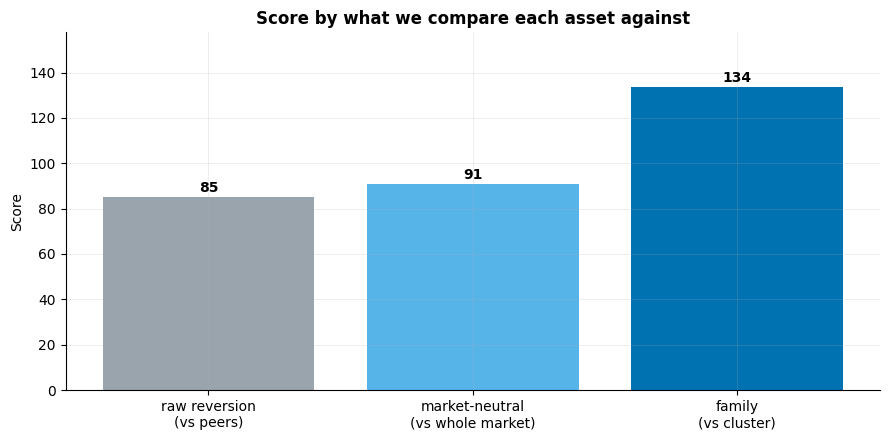

In [8]:
def strat_raw(prcSoFar):        # vs peers, magnitude only (20d + 60d), no market removal
    nI, nt = prcSoFar.shape
    if nt < 62: return np.zeros(nI)
    px = prcSoFar[:, -1]; s = np.zeros(nI)
    for k in (20, 60):
        r = np.log(px / prcSoFar[:, -1 - k]); s += -(r - r.mean())
    s = s / np.clip(np.diff(np.log(prcSoFar), axis=1)[:, -VOL_WINDOW:].std(1), 1e-8, None)
    g = np.abs(s).sum()
    return np.zeros(nI) if g < 1e-12 else ((s / g * GROSS) / px).astype(int)

def strat_market(prcSoFar):     # vs the whole market (remove market beta)
    nI, nt = prcSoFar.shape
    if nt < REVERT_WINDOW + 2: return np.zeros(nI)
    px = prcSoFar[:, -1]; dr = np.diff(np.log(prcSoFar), axis=1)[:, -REVERT_WINDOW:]
    mkt = dr.mean(0); mc = mkt - mkt.mean()
    rc = dr - dr.mean(1, keepdims=True); beta = (rc @ mc) / (mc @ mc)
    resid = (dr - np.outer(beta, mkt)).sum(1); s = -(resid - resid.mean())
    s = s / np.clip(np.diff(np.log(prcSoFar), axis=1)[:, -VOL_WINDOW:].std(1), 1e-8, None)
    g = np.abs(s).sum()
    return np.zeros(nI) if g < 1e-12 else ((s / g * GROSS) / px).astype(int)

names = ['raw reversion\n(vs peers)', 'market-neutral\n(vs whole market)', 'family\n(vs cluster)']
scores = [R.backtest(f, prices)['score'] for f in (strat_raw, strat_market, getMyPosition)]
print('scores:', {n.split(chr(10))[0]: round(s, 1) for n, s in zip(names, scores)})
fig, ax = plt.subplots()
bars = ax.bar(names, scores, color=['#9aa4ad', CAT[5], CAT[0]])
for b, s in zip(bars, scores):
    ax.text(b.get_x() + b.get_width() / 2, s + 2, f'{s:.0f}', ha='center', fontweight='bold')
ax.set_title('Score by what we compare each asset against')
ax.set_ylabel('Score'); ax.set_ylim(0, max(scores) * 1.18)
plt.tight_layout(); plt.show()

## 7. Robustness — is 134 just a lucky setting?

Re-run while varying the two main knobs: number of families, and how much money we deploy.
Score stays high across a wide range — a good sign it isn't a single fluke (still in-sample, though).

Score vs k: {3: np.float64(101.6), 4: np.float64(96.2), 5: np.float64(129.4), 6: np.float64(133.7), 7: np.float64(143.4), 8: np.float64(116.6)}
Score vs gross($M): {0.5: np.float64(84.7), 0.75: np.float64(125.3), 1.0: np.float64(133.7), 1.25: np.float64(139.9), 1.5: np.float64(145.9), 2.0: np.float64(149.3)}


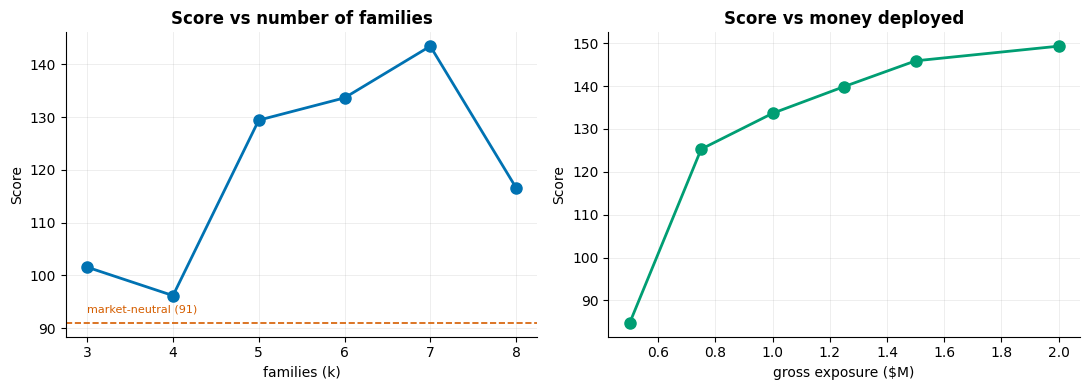

In [9]:
ks = [3, 4, 5, 6, 7, 8]; sc_k = []
for k in ks:
    N_CLUSTERS = k; sc_k.append(R.backtest(getMyPosition, prices)['score'])
N_CLUSTERS = 6

grosses = [0.5, 0.75, 1.0, 1.25, 1.5, 2.0]; sc_g = []
for gm in grosses:
    GROSS = gm * 1e6; sc_g.append(R.backtest(getMyPosition, prices)['score'])
GROSS = 1_000_000

print('Score vs k:', dict(zip(ks, [round(x, 1) for x in sc_k])))
print('Score vs gross($M):', dict(zip(grosses, [round(x, 1) for x in sc_g])))
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4))
a1.plot(ks, sc_k, '-o', color=CAT[0], lw=2, ms=8)
a1.axhline(91, color=CAT[3], ls='--', lw=1.2)
a1.text(ks[0], 93, 'market-neutral (91)', color=CAT[3], fontsize=8)
a1.set_title('Score vs number of families'); a1.set_xlabel('families (k)'); a1.set_ylabel('Score')
a2.plot(grosses, sc_g, '-o', color=CAT[2], lw=2, ms=8)
a2.set_title('Score vs money deployed'); a2.set_xlabel('gross exposure ($M)'); a2.set_ylabel('Score')
plt.tight_layout(); plt.show()

## 8. Honest caveat

Every number above is **in-sample** — measured on the same 250 days we tuned against. We've now
turned several knobs, so expect the real Score on **new data (next stage)** to be lower. The *family
structure* should carry over; the exact 134 won't.

Two things we re-compute the families **every day**, which causes extra trading (churn); smoothing
them, plus a "don't trade tiny changes" band, are the next levers. The honest next step is a
**split-sample test** (tune on the first 125 days, measure on the last 125) to see how much survives.